In [30]:
# [STEP 1] Environment Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

PATH_SAME = 'hotel_bookings.csv'
PATH_DATA = '../data/hotel_bookings.csv'
PATH_ROOT_DATA = 'data/hotel_bookings.csv'

if os.path.exists(PATH_DATA):
    DATA_PATH = PATH_DATA
elif os.path.exists(PATH_ROOT_DATA):
    DATA_PATH = PATH_ROOT_DATA
else:
    DATA_PATH = PATH_SAME

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset loaded from: {DATA_PATH}")
    print(f"Shape: {df.shape}")
else:
    print("Error: CSV file not found. Please check the 'data' folder.")

Dataset loaded from: hotel_bookings.csv
Shape: (119390, 32)


In [31]:
# [STEP 2] Data Cleaning & Outlier Removal
# 1. Column name trimming
df.columns = df.columns.str.strip()

# 2. Fill Missing Values
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
if 'company' in df.columns:
    df.drop('company', axis=1, inplace=True)

# 3. Filter Outliers (Based on EDA)
# Filter ADR (0 < ADR < 500)
df = df[(df['adr'] > 0) & (df['adr'] < 500)]
# Remove bookings with zero guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df = df[df['total_guests'] > 0]

print(f"Cleaning complete. Current records: {len(df)}")

Cleaning complete. Current records: 117396


In [32]:
# [STEP 3] Feature Engineering & Data Leakage Prevention
# 1. Create New Features
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)

# 2. Simplify Country Data (Keep Top 10)
top_10 = df['country'].value_counts().nlargest(10).index
df['country'] = df['country'].apply(lambda x: x if x in top_10 else 'Other')

# 3. Drop Leakage Columns (Critical for Modeling)
leak_cols = ['reservation_status', 'reservation_status_date']
df.drop([c for c in leak_cols if c in df.columns], axis=1, inplace=True)

print("Feature engineering and leakage prevention applied.")

Feature engineering and leakage prevention applied.


In [33]:
# [STEP 4] One-Hot Encoding for Categorical Features
cat_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 
            'deposit_type', 'customer_type', 'arrival_date_month', 'country']

# Convert categorical data into numeric dummies
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Final dataset prepared. Columns increased to: {df_final.shape[1]}")

Final dataset prepared. Columns increased to: 66


Total Missing Values in Final Data: 0


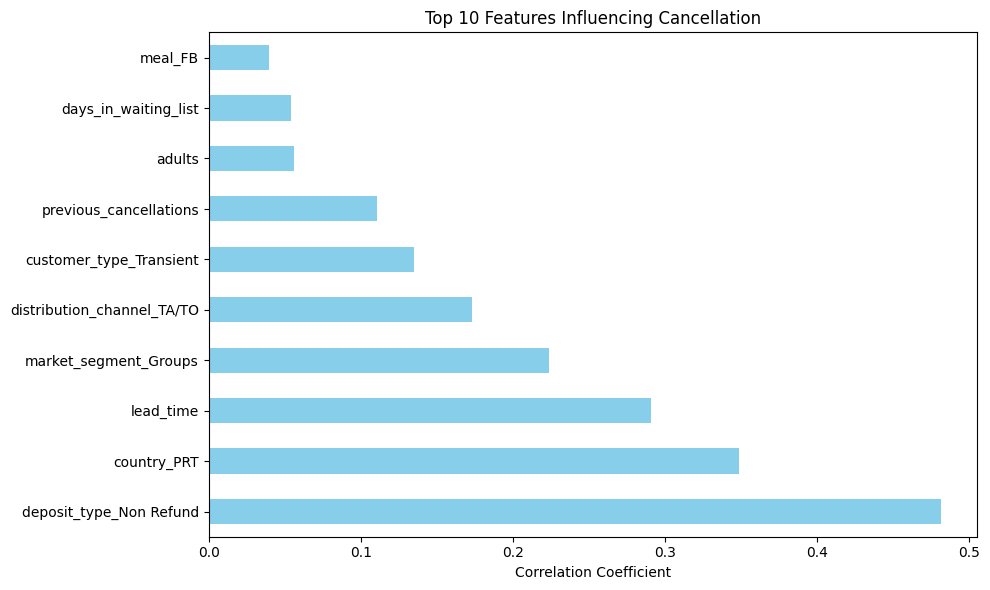

In [34]:
# [STEP 5] Verification & Quality Check
# 1. Check for missing values
print(f"Total Missing Values in Final Data: {df_final.isnull().sum().sum()}")

# 2. Correlation Plot (Check impact on is_canceled)
plt.figure(figsize=(10, 6))
# Using numeric_only=True to prevent ValueError
corr_series = df_final.corr(numeric_only=True)['is_canceled'].sort_values(ascending=False)
corr_series.head(11).tail(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Features Influencing Cancellation')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [35]:
# [STEP 6] Saving Processed Data
output_dir = '../data/' if os.path.exists('../data/') else ''

clf_output = os.path.join(output_dir, 'hotel_bookings_clf.csv')
reg_output = os.path.join(output_dir, 'hotel_bookings_reg.csv')

# 1. Classification Data
df_final.to_csv(clf_output, index=False)

# 2. Regression Data
df_reg = df_final[df_final['is_canceled'] == 0].copy()
df_reg.to_csv(reg_output, index=False)

print(f"Success! Files saved in: {os.path.abspath(output_dir)}")

Success! Files saved in: c:\Users\양수겸\Desktop\데과팀플
